# 9 · Building a short-horizon signal, and watching costs destroy it

**The question:** we've found several things that predict short-term price moves (imbalance, order flow).
Put them together. Is there money in it?

This chapter is about **honest evaluation**, the skill interviewers probe most when you say "I built a
trading model":
1. Train on the past, test on the future, never the other way round.
2. Measure out-of-sample, with the right metric.
3. Subtract realistic costs: spread, fees, and the price moving while you react (latency).
4. Know how easily you can fool yourself (overfitting, data snooping).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from micro.data import load_quotes, load_trades, aggregate_trades
from micro.book import mid, imbalance, ofi_events, to_ms, resample_last, sum_in_buckets, time_grid
from micro.stats import ols, binned_mean
from micro.plotting import style, save, BLUE, ORANGE, GREEN, GREY, RED

style()
quotes = load_quotes()
orders = aggregate_trades(load_trades())
qts, m = to_ms(quotes.ts), mid(quotes)
ots = to_ms(orders.ts)
e = ofi_events(quotes.bid, quotes.bid_qty, quotes.ask, quotes.ask_qty)
I = imbalance(quotes.bid_qty, quotes.ask_qty)
spread = (quotes.ask - quotes.bid).to_numpy()

## Features and target, sampled once per second

At each second t we only use information available **at or before t**:

| feature | meaning |
|---|---|
| `imb` | queue imbalance I − ½ at time t (chapter 6) |
| `ofi_1s` | order flow imbalance over the last second (chapter 5) |
| `tfi_1s` | net aggressive volume over the last second |
| `ret_1s`, `ret_10s` | mid change over the last 1 s and 10 s (momentum or reversal?) |

Target: mid change over the **next** second.

In [2]:
grid = time_grid(qts[0] + np.timedelta64(10, "s"), qts[-1] - np.timedelta64(10, "s"), "1s")
mid_now = resample_last(qts, m, grid)

def mid_later(seconds):
    return resample_last(qts, m, grid + np.timedelta64(int(seconds * 1000), "ms"))

df = pd.DataFrame({
    "imb": resample_last(qts, I, grid) - 0.5,
    "ofi_1s": np.r_[np.nan, sum_in_buckets(qts, e, grid)],
    "tfi_1s": np.r_[np.nan, sum_in_buckets(ots, orders.sign.to_numpy() * orders.qty.to_numpy(), grid)],
    "ret_1s": np.r_[np.nan, np.diff(mid_now)],
    "ret_10s": mid_now - resample_last(qts, m, grid - np.timedelta64(10, "s")),
    "spread": resample_last(qts, spread, grid),
    "target": mid_later(1) - mid_now,
}).dropna()
features = ["imb", "ofi_1s", "tfi_1s", "ret_1s", "ret_10s"]

# Chronological split: first half of the day to fit, second half to test.
split = len(df) // 2
train, test = df.iloc[:split], df.iloc[split:]
print(f"train: {len(train):,} seconds   test: {len(test):,} seconds")

train: 43,189 seconds   test: 43,190 seconds


## Fit on the morning, test on the afternoon

In [3]:
model = ols(train.target, train[features], hac_lags=10, names=features)
print(model)

def predict(d):
    return model.beta[0] + d[features].to_numpy() @ model.beta[1:]

pred = predict(test)
y = test.target.to_numpy()
r2_oos = 1 - np.sum((y - pred) ** 2) / np.sum((y - train.target.mean()) ** 2)
moved = y != 0
print(f"\nin-sample R²:      {model.r2:.3f}")
print(f"out-of-sample R²:  {r2_oos:.3f}")
print(f"correlation(prediction, outcome) out of sample: {np.corrcoef(pred, y)[0, 1]:.3f}")
print(f"direction hit rate, when the mid moved at all: {np.mean(np.sign(pred[moved]) == np.sign(y[moved])):.1%}")

OLS(n=43,189, R2=0.0952)
             coef  std err      t
const     0.01016  0.02226 0.4565
imb         3.801  0.07904  48.08
ofi_1s      0.011  0.00137  8.023
tfi_1s   -0.01346 0.007348 -1.832
ret_1s   -0.01555   0.0114 -1.364
ret_10s -0.004131  0.00192 -2.152

in-sample R²:      0.095
out-of-sample R²:  0.037
correlation(prediction, outcome) out of sample: 0.196
direction hit rate, when the mid moved at all: 69.2%


- **Imbalance dominates** (t ≈ 48). OFI adds a little. Past returns and trade flow are weak or slightly
  negative (mild reversal).
- Out-of-sample R² is lower than in-sample (always check this gap), but positive. The signal is real and stable
  across the two halves of the day.
- When the price moves at all within the next second, the signal calls the direction right well over half
  the time.

By prediction standards, that's a genuinely good signal. Now the money question.

## Gross edge vs costs

A simple strategy: when the signal says up, **buy**, and sell one second later. As a **taker** you cross
the spread on the way in and on the way out. Relative to the mid that costs half a spread each way, so one
full spread per round trip. Plus the exchange fee on both legs.

Fees (Binance USDⓈ-M futures, regular tier, 2024): **0.02% maker, 0.05% taker** per side. High-volume VIP
tiers pay several times less. (Check binance.com/en/fee/futureFee for current numbers.)

gross edge, strongest 10% of signals: 3.36 USDT per BTC  (0.48 bp)
spread cost (round trip, taker):     0.26 USDT
taker fees, round trip at 0.05%:     70 USDT
maker fees, round trip at 0.02%:     28 USDT


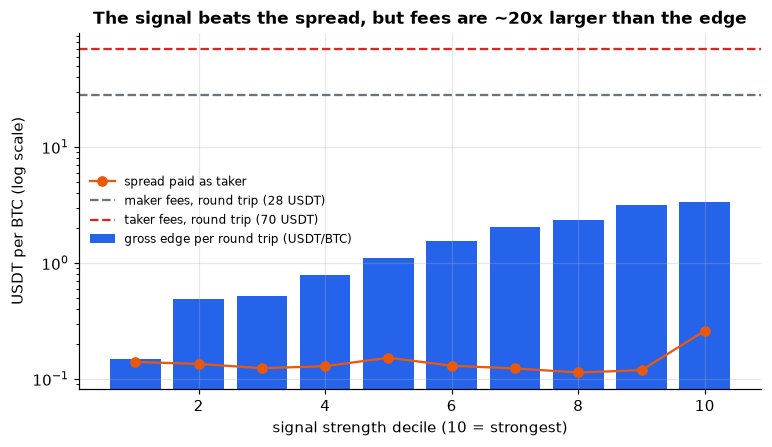

In [4]:
deciles = pd.qcut(np.abs(pred), 10, labels=False)
gross = np.sign(pred) * y          # USDT gained per BTC if you could trade at the mid, no costs
table = pd.DataFrame({"decile": deciles, "gross": gross, "spread": test.spread.to_numpy()}).groupby("decile").mean()
price = m.mean()
fee_taker_round_trip = 2 * 0.0005 * price
fee_maker_round_trip = 2 * 0.0002 * price
print(f"gross edge, strongest 10% of signals: {table.gross.iloc[-1]:.2f} USDT per BTC  ({table.gross.iloc[-1] / price * 1e4:.2f} bp)")
print(f"spread cost (round trip, taker):     {table.spread.iloc[-1]:.2f} USDT")
print(f"taker fees, round trip at 0.05%:     {fee_taker_round_trip:.0f} USDT")
print(f"maker fees, round trip at 0.02%:     {fee_maker_round_trip:.0f} USDT")

fig, ax = plt.subplots()
ax.bar(table.index + 1, table.gross, color=BLUE, label="gross edge per round trip (USDT/BTC)")
ax.plot(table.index + 1, table.spread, "o-", color=ORANGE, label="spread paid as taker")
ax.axhline(fee_maker_round_trip, color=GREY, ls="--", label=f"maker fees, round trip ({fee_maker_round_trip:.0f} USDT)")
ax.axhline(fee_taker_round_trip, color=RED, ls="--", label=f"taker fees, round trip ({fee_taker_round_trip:.0f} USDT)")
ax.set(yscale="log", xlabel="signal strength decile (10 = strongest)", ylabel="USDT per BTC (log scale)",
       title="The signal beats the spread, but fees are ~20x larger than the edge")
ax.legend(fontsize=8, loc="center left")
save(fig, "09_edge_vs_costs")

This is the core lesson of HFT economics:

- The edge is **real**: a few USDT per BTC, comfortably more than the 0.1–0.3 USDT spread.
- But it's about **0.4–0.5 bp** of the price. Exchange fees for an ordinary account are **10 bp** per round
  trip as a taker. Fees are about 20 times the edge.

So who *can* use signals like this? Firms whose cost structure is completely different:
- **Market makers** who mostly trade passively, pay low or *negative* maker fees (rebates) at top volume tiers,
  and use the signal to decide *when not to quote*, not to take positions.
- **Execution algorithms** that must trade anyway: if you have to buy 100 BTC today, waiting for a favourable
  imbalance before each child order saves real money without paying any extra fees.

## Latency: the edge decays while you react

Our backtest assumed you trade at the exact instant the signal is computed. In reality there's a delay:
the market data has to reach you, your code has to run, your order has to reach the exchange.

In [5]:
rows = []
for latency_ms in [0, 10, 50, 100, 250, 500, 1000]:
    t0 = grid + np.timedelta64(latency_ms, "ms")
    start = resample_last(qts, m, t0)
    end = resample_last(qts, m, t0 + np.timedelta64(1000, "ms"))
    move = pd.Series(end - start, index=pd.RangeIndex(len(grid)))
    move = move.loc[df.index].to_numpy()[split:]
    top = deciles == 9
    rows.append({"latency (ms)": latency_ms, "gross edge, top decile (USDT)": np.nanmean(np.sign(pred[top]) * move[top])})
lat = pd.DataFrame(rows).set_index("latency (ms)")
print(lat.round(2))

              gross edge, top decile (USDT)
latency (ms)                               
0                                      3.36
10                                     3.24
50                                     2.80
100                                    2.43
250                                    1.89
500                                    1.41
1000                                   0.88


Every millisecond of delay costs edge: about a quarter is gone at 100 ms and half by roughly 300 ms. Other fast
traders see the same imbalance and act first. This is why HFT firms co-locate servers in the exchange's data
centre and fight over microseconds. The signal is shared, so the race is about who acts on it first.

## How to fool yourself: overfitting

Add 100 features of **pure noise** to the model and refit.

In [6]:
rng = np.random.default_rng(0)
noise_cols = [f"noise_{k}" for k in range(300)]
noise = pd.DataFrame(rng.normal(size=(len(df), 300)), columns=noise_cols, index=df.index)
big = pd.concat([df, noise], axis=1)
tst = big.iloc[split:]
rows = []
for train_name, trn in [("12 hours", big.iloc[:split]), ("30 minutes", big.iloc[:1800])]:
    for k in [0, 30, 100, 300]:
        cols = features + noise_cols[:k]
        r = ols(trn.target, trn[cols], names=cols)
        p = r.beta[0] + tst[cols].to_numpy() @ r.beta[1:]
        yy = tst.target.to_numpy()
        rows.append({"training data": train_name, "noise features": k, "in-sample R²": r.r2,
                     "out-of-sample R²": 1 - np.sum((yy - p) ** 2) / np.sum((yy - trn.target.mean()) ** 2),
                     "noise coefs with |t| > 2": int(np.sum(np.abs(r.t[1 + len(features):]) > 2))})
print(pd.DataFrame(rows).set_index(["training data", "noise features"]).round(4))

                              in-sample R²  out-of-sample R²  \
training data noise features                                   
12 hours      0                     0.0952            0.0368   
              30                    0.0961            0.0368   
              100                   0.0981            0.0363   
              300                   0.1023            0.0351   
30 minutes    0                     0.1433            0.0144   
              30                    0.1585            0.0089   
              100                   0.1967           -0.0004   
              300                   0.2787           -0.0182   

                              noise coefs with |t| > 2  
training data noise features                            
12 hours      0                                      0  
              30                                     1  
              100                                    8  
              300                                   18  
30 minutes    0  

In-sample R² can only go **up** when you add regressors, even useless ones. Out-of-sample R² goes **down**.
How much depends on the ratio of parameters to data:

- With 12 hours (43,000 seconds) of training data, even 300 junk features barely hurt.
- With 30 minutes (1,800 seconds), the junk inflates in-sample R² a lot, and out-of-sample R² collapses,
  eventually below zero (worse than predicting the average).

In both cases about 5% of the pure-noise features come out "significant" at |t| > 2, exactly as a 5% test
promises. Try 1,000 candidate signals and you'll "discover" ~50. This is **data snooping**. The defences: a
held-out test set you look at *once*, adjusting for the number of things you tried (Bonferroni, false
discovery rate), and an economic story for why the signal should exist.

---
### Interview angle

<details><summary><b>"Your signal has a t-stat of 48. Should we trade it?"</b></summary>

Statistical significance ≠ profitability. Ask: (1) out-of-sample performance on later data; (2) size of the
edge per trade vs spread + fees + impact; (3) latency: how fast does it decay, and are we fast enough; (4) capacity:
how much can we trade before our own impact eats it; (5) how many things were tried before this one was found.
</details>

<details><summary><b>"Your backtest makes money. List everything that could be wrong with it."</b></summary>

Look-ahead bias (using data not yet available, e.g. same-millisecond quotes); no transaction costs or wrong
fees; assuming fills at the mid; ignoring latency; ignoring your own market impact; overfitting / data
snooping; non-stationarity (one day of data!); survivorship bias in the asset universe; ignoring
queue position for passive fills (you don't get filled when you most want to: adverse selection, chapter 4).
</details>

<details><summary><b>"Why does in-sample R² always rise when you add a variable?"</b></summary>

OLS minimises the in-sample sum of squared residuals. Adding a column can't make the minimum worse, because the
optimiser could always set its coefficient to zero. Adjusted R² and information criteria (AIC/BIC) penalise
extra parameters, but the real test is out of sample.
</details>

### Try this yourself
1. Instead of taking, simulate **passive** entry: post at the bid when the signal says up. You only get filled if
   the price trades down to you. What happens to the average outcome *conditional on being filled*?
2. Use 10-second targets instead of 1-second. Does the edge/cost ratio improve?